In [1]:
# what featrures does this have

import h5py

file = h5py.File('/Users/wen/Desktop/project/archive/5x64x64_training_with_morphology.hdf5','r')

print(list(file.keys()))

['coord', 'dec', 'g_central_image_pop_10px_rad', 'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad', 'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity', 'g_half_light_radius', 'g_isophotal_area', 'g_major_axis', 'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad', 'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad', 'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad', 'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity', 'i_half_light_radius', 'i_isophotal_area', 'i_major_axis', 'i_minor_axis', 'i_peak_surface_brightness', 'i_petro_rad', 'i_pos_angle', 'i_sersic_index', 'image', 'object_id', 'r_central_image_pop_10px_rad', 'r_central_image_pop_15px_rad', 'r_central_image_pop_5px_rad', 'r_cmodel_mag', 'r_cmodel_magsigma', 'r_ellipticity', 'r_half_light_radius', 'r_isophotal_area', 'r_major_axis', 'r_minor_axis', 'r_peak_surface_brightness', 'r_petro_rad', 'r_pos_angle', 'r_sersic_index', 'ra', 'skymap_id', 'specz_dec', 'specz_flag_homogeneous', 

In [2]:
for key in file.keys():
    print(key, file[key].shape)

coord (204573,)
dec (204573,)
g_central_image_pop_10px_rad (204573,)
g_central_image_pop_15px_rad (204573,)
g_central_image_pop_5px_rad (204573,)
g_cmodel_mag (204573,)
g_cmodel_magsigma (204573,)
g_ellipticity (204573,)
g_half_light_radius (204573,)
g_isophotal_area (204573,)
g_major_axis (204573,)
g_minor_axis (204573,)
g_peak_surface_brightness (204573,)
g_petro_rad (204573,)
g_pos_angle (204573,)
g_sersic_index (204573,)
i_central_image_pop_10px_rad (204573,)
i_central_image_pop_15px_rad (204573,)
i_central_image_pop_5px_rad (204573,)
i_cmodel_mag (204573,)
i_cmodel_magsigma (204573,)
i_ellipticity (204573,)
i_half_light_radius (204573,)
i_isophotal_area (204573,)
i_major_axis (204573,)
i_minor_axis (204573,)
i_peak_surface_brightness (204573,)
i_petro_rad (204573,)
i_pos_angle (204573,)
i_sersic_index (204573,)
image (204573, 5, 64, 64)
object_id (204573,)
r_central_image_pop_10px_rad (204573,)
r_central_image_pop_15px_rad (204573,)
r_central_image_pop_5px_rad (204573,)
r_cmodel_m

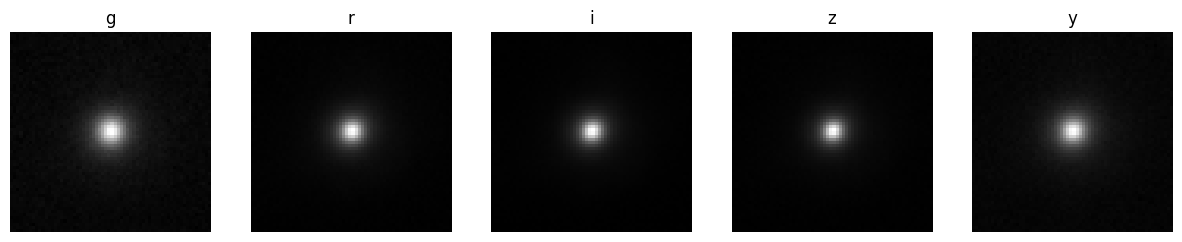

In [13]:
idx = 1024
img = file['image'][idx]

fig,axs = plt.subplots(1,5,figsize=(15,3))

bands = ['g','r','i','z','y']

for i in range(5):
    axs[i].imshow(img[i], cmap='gray')
    axs[i].set_title(bands[i])
    axs[i].axis('off')

plt.show()

# same galaxy, diff bands

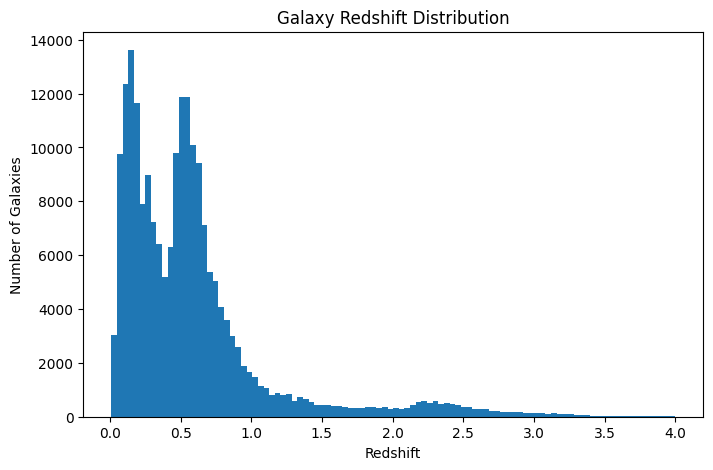

In [6]:
z = file['specz_redshift'][:]

plt.figure(figsize=(8,5))
plt.hist(z, bins=100)
plt.xlabel("Redshift")
plt.ylabel("Number of Galaxies")
plt.title("Galaxy Redshift Distribution")
plt.show()

# z larger, older and further galaxies

z range 0-0.5 galaxies: 105195


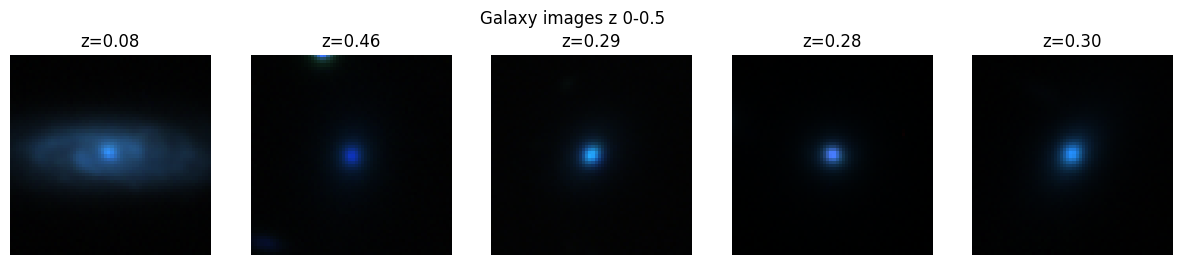

z range 0.5-1 galaxies: 74382


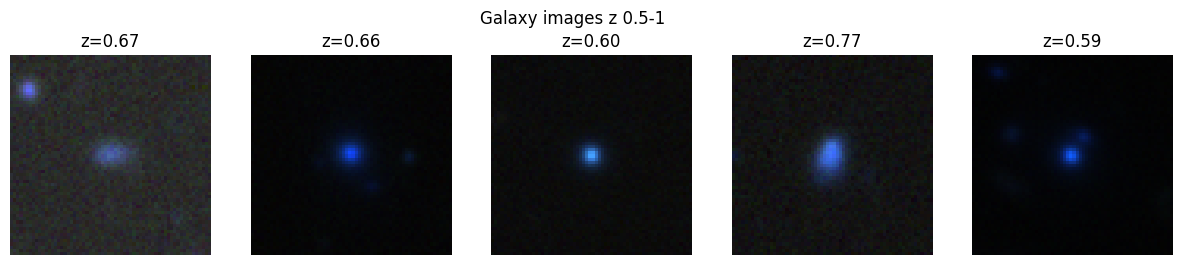

z range 1-2 galaxies: 14842


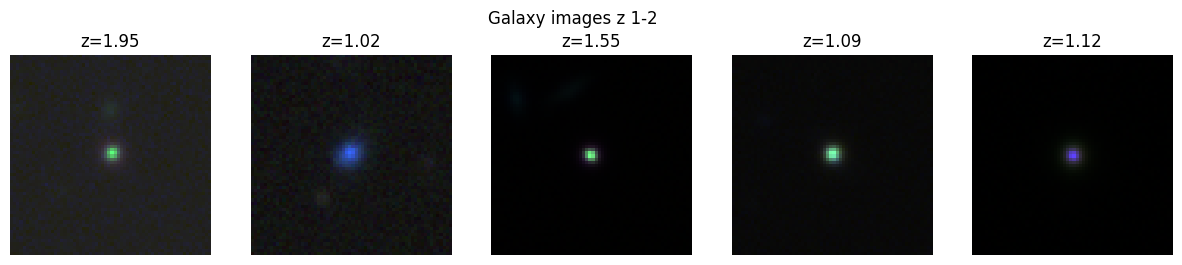

z range 2-3 galaxies: 8592


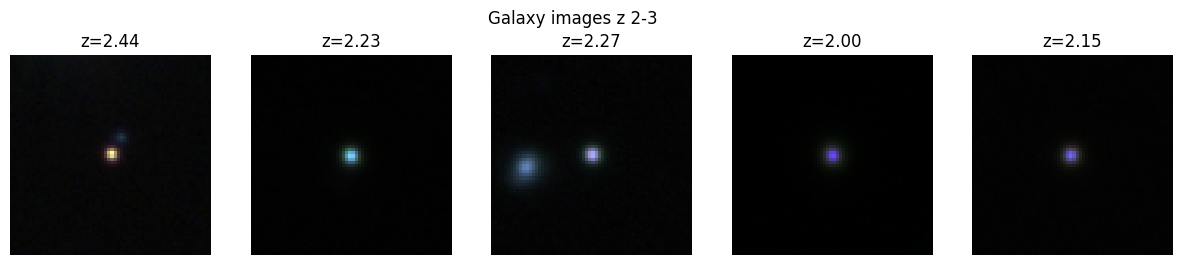

z range 3-4 galaxies: 1562


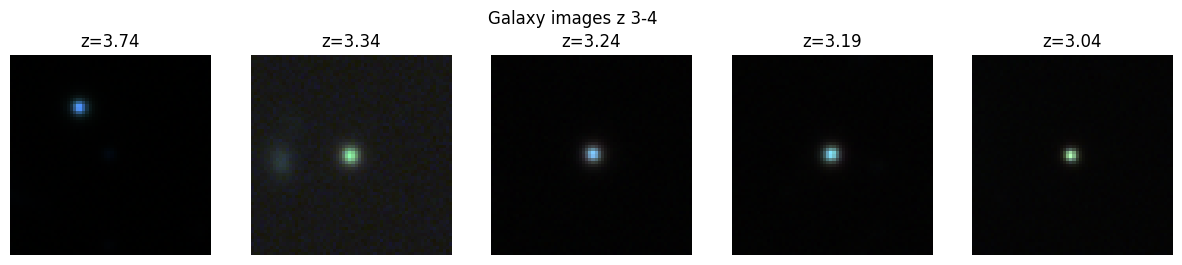

In [ ]:
import numpy as np

images = file['image']
z = file['specz_redshift'][:]

bins = [(0,0.5),(0.5,1),(1,2),(2,3),(3,4)]

for zmin,zmax in bins:

    idx = np.where((z>=zmin)&(z<zmax))[0]

    print(f"z range {zmin}-{zmax} galaxies:",len(idx))

    sample = np.random.choice(idx,5)

    fig,axs = plt.subplots(1,5,figsize=(15,3))

    for i,id in enumerate(sample):

        img = images[id]

        # combine g r i into RGB
        rgb = np.stack([img[0],img[1],img[2]],axis=-1)

        rgb = (rgb-rgb.min())/(rgb.max()-rgb.min()+1e-5)   # normalize, avoide overexposure or too dark

        axs[i].imshow(rgb)
        axs[i].axis("off")
        axs[i].set_title(f"z={z[id]:.2f}")

    plt.suptitle(f"Galaxy images z {zmin}-{zmax}")
    plt.show()

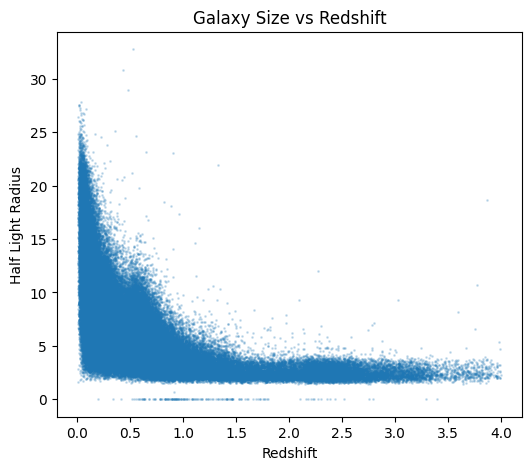

In [8]:
r = file['r_half_light_radius'][:]

plt.figure(figsize=(6,5))
plt.scatter(z,r,s=1,alpha=0.2)
plt.xlabel("Redshift")
plt.ylabel("Half Light Radius")
plt.title("Galaxy Size vs Redshift")
plt.show()

## Redshift vs. color, morphology
from HSC test set


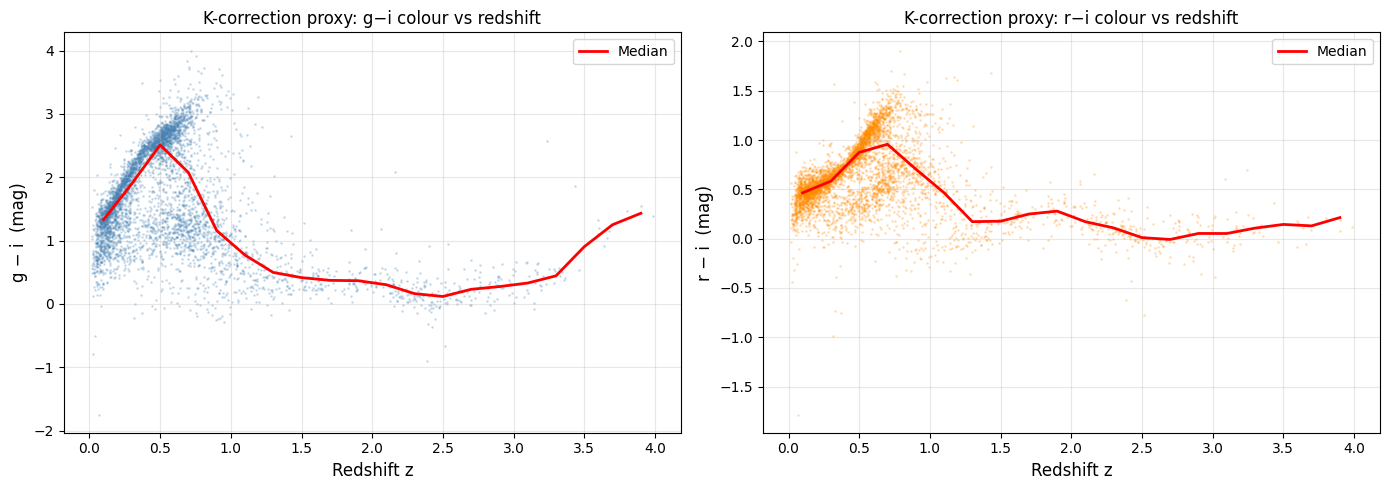

Saved: colour_vs_redshift.png


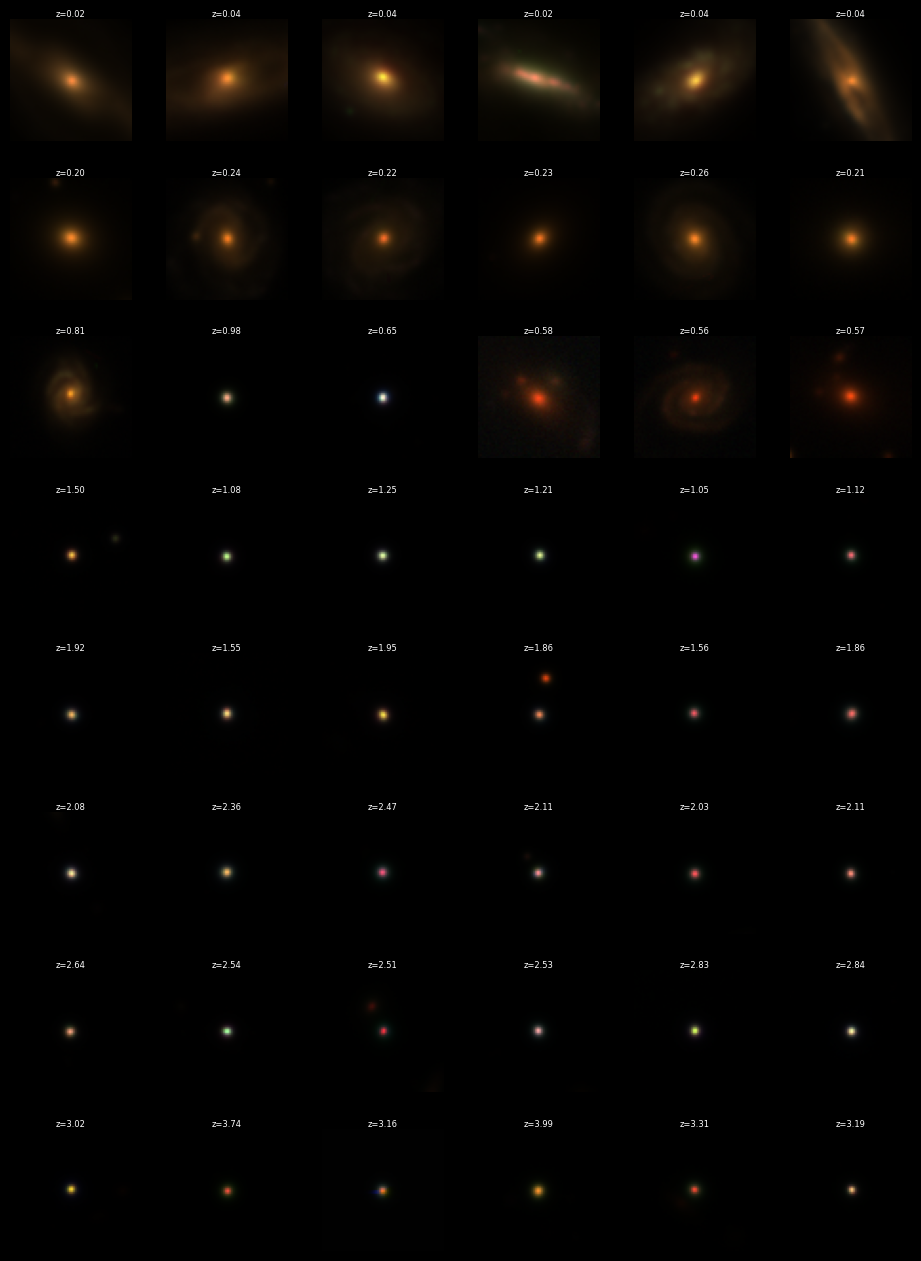

Saved: galaxy_colour_evolution.png


In [ ]:
"""
Part 1: Color & morphology evolution with redshift — K-correction check
- (g-i) colour index vs z: if K-correction visible, redder at higher z
- Image strip: for each z bin, pick 5 brightest-i galaxies, display RGB
"""
import numpy as np
import matplotlib.pyplot as plt
import h5py

HDF5 = '/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5'

with h5py.File(HDF5, 'r') as f:
    z      = f['specz_redshift'][:]
    g_mag  = f['g_cmodel_mag'][:]
    r_mag  = f['r_cmodel_mag'][:]
    i_mag  = f['i_cmodel_mag'][:]
    images = f['image'][:]          # load all into memory for speed

# ── 1A: colour index vs redshift ─────────────────────────────────────────────

# mobs​=mtrue​+K(z)
# proxy： using g-i and r -i represent K
gi = g_mag - i_mag   # g-i colour   两个波段星等之差。larger index, diff larger, more red
ri = r_mag - i_mag

# clip extreme outliers
mask = (gi > -2) & (gi < 6) & (z < 4.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scatter (subsample for speed) randomly choose 5000 dots
idx_sub = np.random.choice(np.where(mask)[0], 5000, replace=False)
axes[0].scatter(z[idx_sub], gi[idx_sub], s=1, alpha=0.2, color='steelblue')
# running median
z_bins = np.arange(0, 4.1, 0.2)
bin_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
medians = [np.median(gi[mask & (z >= lo) & (z < hi)])
           for lo, hi in zip(z_bins[:-1], z_bins[1:])]
axes[0].plot(bin_centers, medians, 'r-', linewidth=2, label='Median')
axes[0].set_xlabel('Redshift z', fontsize=12)
axes[0].set_ylabel('g − i  (mag)', fontsize=12)
axes[0].set_title('K-correction proxy: g−i colour vs redshift', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(z[idx_sub], ri[idx_sub], s=1, alpha=0.2, color='darkorange')
medians_ri = [np.median(ri[mask & (z >= lo) & (z < hi)])
              for lo, hi in zip(z_bins[:-1], z_bins[1:])]
axes[1].plot(bin_centers, medians_ri, 'r-', linewidth=2, label='Median')
axes[1].set_xlabel('Redshift z', fontsize=12)
axes[1].set_ylabel('r − i  (mag)', fontsize=12)
axes[1].set_title('K-correction proxy: r−i colour vs redshift', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('colour_vs_redshift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: colour_vs_redshift.png")

# ── 1B: image strip across z bins ────────────────────────────────────────────
# only choose i brightness

def to_rgb(img):
    """i→R, r→G, g→B, linear stretch"""
    rgb = img[[2, 1, 0]].astype(float)
    rgb = np.transpose(rgb, (1, 2, 0))
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    return np.clip(rgb, 0, 1)

Z_BINS = [(0.0, 0.2), (0.2, 0.5), (0.5, 1.0), (1.0, 1.5),
          (1.5, 2.0), (2.0, 2.5), (2.5, 3.0), (3.0, 4.0)]
N_PER_BIN = 6

fig, axes = plt.subplots(len(Z_BINS), N_PER_BIN, figsize=(N_PER_BIN*2, len(Z_BINS)*2))
fig.patch.set_facecolor('black')

for row_i, (zlo, zhi) in enumerate(Z_BINS):
    bin_idx = np.where((z >= zlo) & (z < zhi))[0]
    # pick brightest-i galaxies (smallest i_mag value)
    brightest = bin_idx[np.argsort(i_mag[bin_idx])[:N_PER_BIN*3]]   # i 波段最亮
    chosen = brightest[:N_PER_BIN]
    for col_i in range(N_PER_BIN):
        ax = axes[row_i, col_i]
        if col_i < len(chosen):
            ax.imshow(to_rgb(images[chosen[col_i]]))
            ax.set_title(f'z={z[chosen[col_i]]:.2f}', color='white', fontsize=6, pad=1)
        ax.axis('off')
    axes[row_i, 0].set_ylabel(f'z {zlo}-{zhi}', color='white', fontsize=8)

plt.subplots_adjust(wspace=0.04, hspace=0.3)
plt.savefig('galaxy_colour_evolution.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("Saved: galaxy_colour_evolution.png")

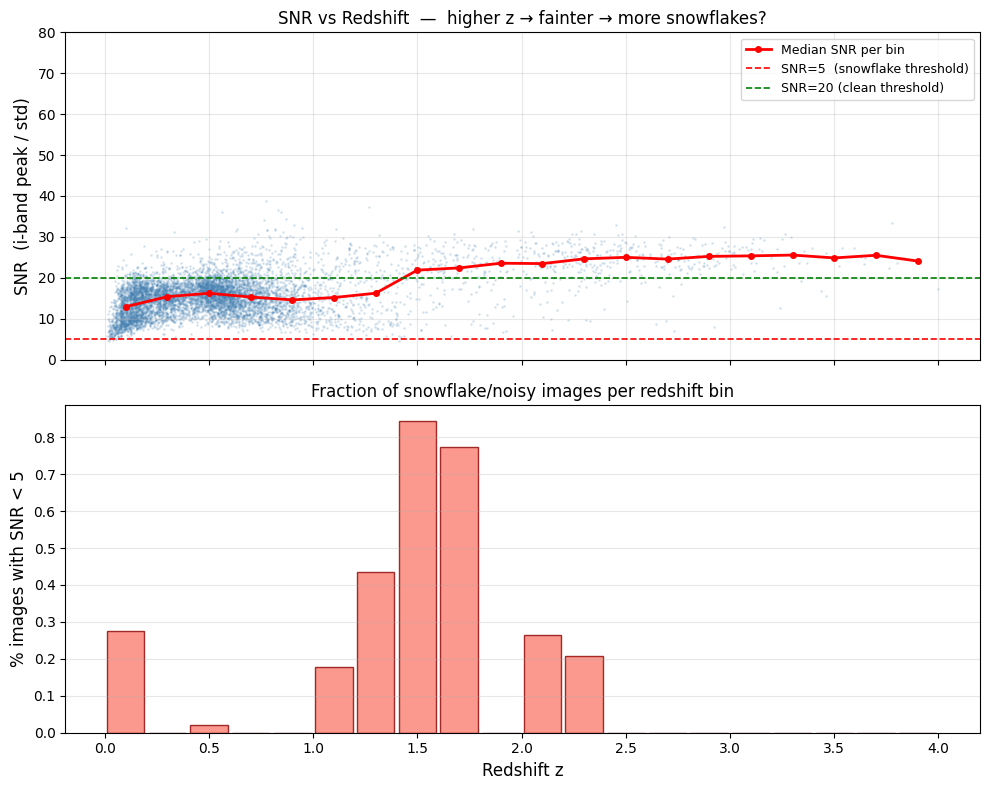

Saved: snr_vs_redshift.png

Median SNR by redshift bin:
  z=0.1: median SNR=12.9,  snowflake%=0.3%
  z=0.3: median SNR=15.4,  snowflake%=0.0%
  z=0.5: median SNR=16.2,  snowflake%=0.0%
  z=0.7: median SNR=15.3,  snowflake%=0.0%
  z=0.9: median SNR=14.6,  snowflake%=0.0%
  z=1.1: median SNR=15.2,  snowflake%=0.2%
  z=1.3: median SNR=16.2,  snowflake%=0.4%
  z=1.5: median SNR=21.9,  snowflake%=0.8%
  z=1.7: median SNR=22.4,  snowflake%=0.8%
  z=1.9: median SNR=23.6,  snowflake%=0.0%
  z=2.1: median SNR=23.5,  snowflake%=0.3%
  z=2.3: median SNR=24.6,  snowflake%=0.2%
  z=2.5: median SNR=25.0,  snowflake%=0.0%
  z=2.7: median SNR=24.6,  snowflake%=0.0%
  z=2.9: median SNR=25.2,  snowflake%=0.0%
  z=3.1: median SNR=25.4,  snowflake%=0.0%
  z=3.3: median SNR=25.6,  snowflake%=0.0%
  z=3.5: median SNR=24.9,  snowflake%=0.0%
  z=3.7: median SNR=25.5,  snowflake%=0.0%
  z=3.9: median SNR=24.1,  snowflake%=0.0%


In [8]:
"""
SNR vs Redshift — does higher z mean more snowflakes?
"""
import numpy as np
import matplotlib.pyplot as plt

# snrs and z_all already computed in the cell above

z_bins   = np.arange(0, 4.1, 0.2)
centers  = 0.5 * (z_bins[:-1] + z_bins[1:])

median_snr = []
pct_noisy  = []   # fraction with SNR < 5

for lo, hi in zip(z_bins[:-1], z_bins[1:]):
    mask = (z_all >= lo) & (z_all < hi)
    if mask.sum() == 0:
        median_snr.append(np.nan)
        pct_noisy.append(np.nan)
    else:
        median_snr.append(np.median(snrs[mask]))
        pct_noisy.append((snrs[mask] < 5).mean() * 100)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ── top: scatter + median line ────────────────────────────────────────────────
idx_sub = np.random.choice(len(z_all), 8000, replace=False)
ax1.scatter(z_all[idx_sub], snrs[idx_sub], s=1, alpha=0.15, color='steelblue')
ax1.plot(centers, median_snr, 'r-o', linewidth=2, markersize=4, label='Median SNR per bin')
ax1.axhline(5,  color='red',   linestyle='--', linewidth=1.2, label='SNR=5  (snowflake threshold)')
ax1.axhline(20, color='green', linestyle='--', linewidth=1.2, label='SNR=20 (clean threshold)')
ax1.set_ylabel('SNR  (i-band peak / std)', fontsize=12)
ax1.set_title('SNR vs Redshift  —  higher z → fainter → more snowflakes?', fontsize=12)
ax1.set_ylim(0, 80)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── bottom: % noisy per bin ───────────────────────────────────────────────────
ax2.bar(centers, pct_noisy, width=0.18, color='salmon', edgecolor='darkred', alpha=0.8)
ax2.set_xlabel('Redshift z', fontsize=12)
ax2.set_ylabel('% images with SNR < 5', fontsize=12)
ax2.set_title('Fraction of snowflake/noisy images per redshift bin', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

# for x, y in zip(centers, pct_noisy):
#     if not np.isnan(y):
#         ax2.text(x, y + 0.3, f'{y:.1f}%', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('snr_vs_redshift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: snr_vs_redshift.png")

# summary
print("\nMedian SNR by redshift bin:")
for c, m, p in zip(centers, median_snr, pct_noisy):
    if not np.isnan(m):
        print(f"  z={c:.1f}: median SNR={m:.1f},  snowflake%={p:.1f}%")

Computing SNR for all test images...
Done. SNR range: 3.9 – 45.5
SNR < 5.0: 42 images (0.1%)  ← likely snowflakes
SNR 5.0-20.0: 34678 images
SNR ≥ 20.0: 6194 images  ← clean galaxies


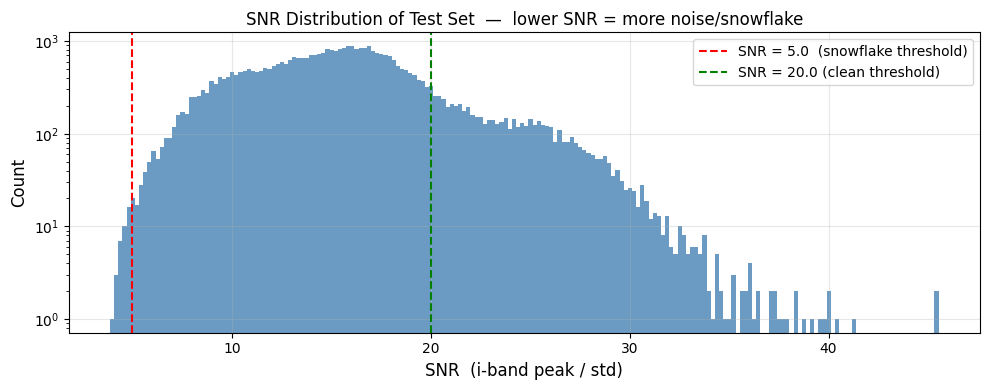

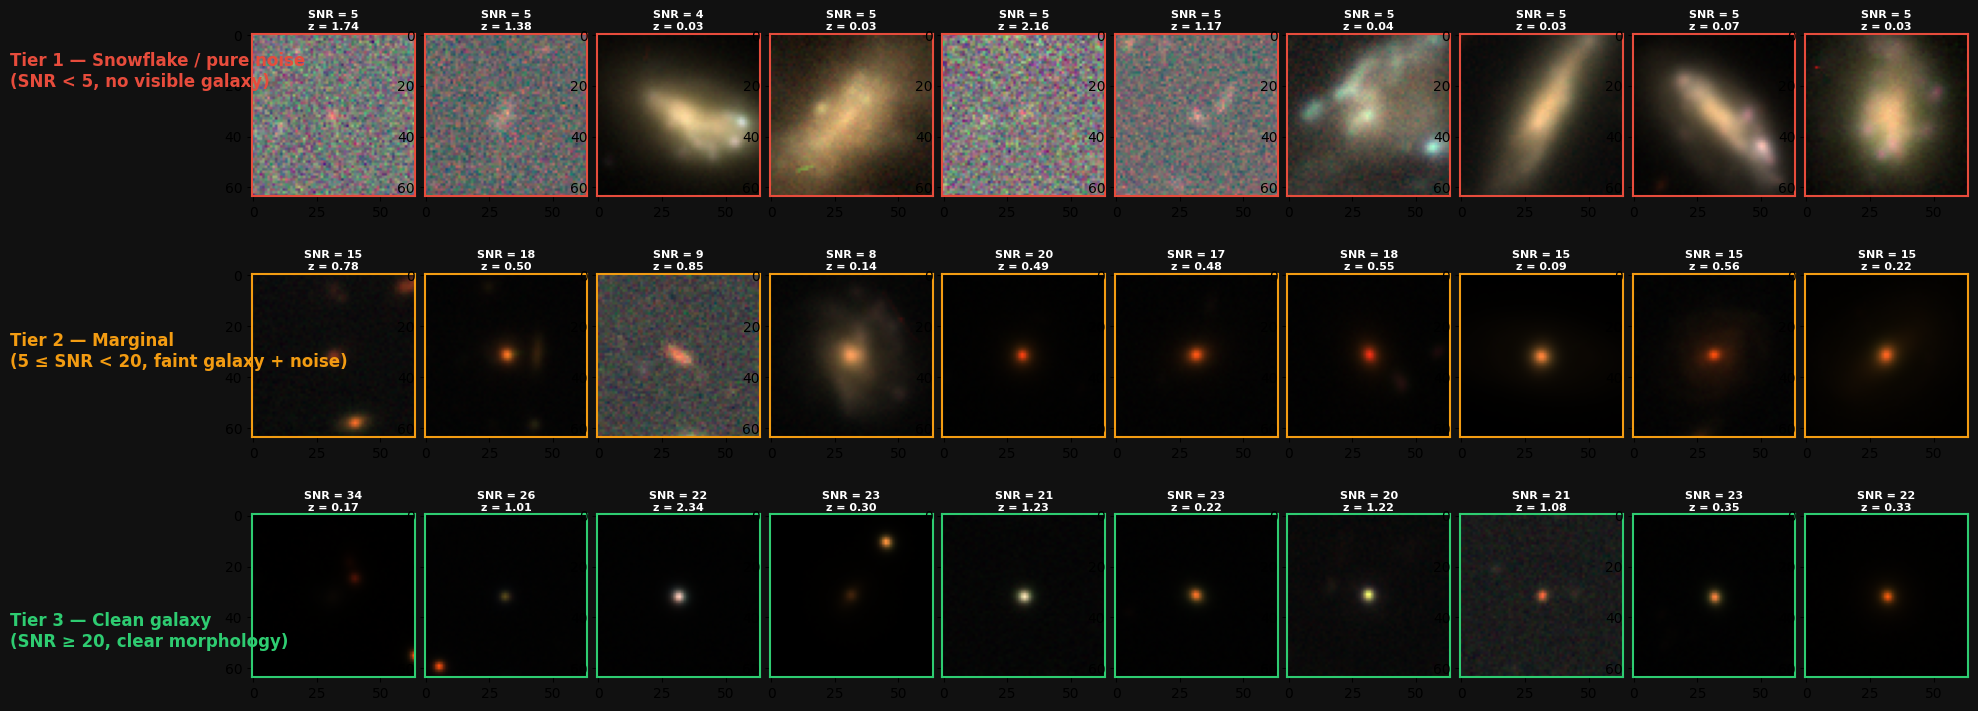

Saved: snr_distribution.png, noisy_image_examples.png


In [9]:
"""
Part 2: Noisy image detection in test set
SNR = i-band peak / i-band std
  SNR < 5  → snowflake / noise dominated (no visible galaxy)
  5-20     → marginal (faint galaxy, some noise)
  ≥ 20     → clean galaxy
"""
import numpy as np
import matplotlib.pyplot as plt
import h5py

HDF5 = '/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5'

print("Computing SNR for all test images...")
with h5py.File(HDF5, 'r') as f:
    n = f['image'].shape[0]
    z_all = f['specz_redshift'][:]
    snrs = np.zeros(n)
    BATCH = 1000
    for start in range(0, n, BATCH):
        batch  = f['image'][start:start+BATCH]
        i_band = batch[:, 2].astype(float)
        snrs[start:start+BATCH] = i_band.max(axis=(1,2)) / (i_band.std(axis=(1,2)) + 1e-8)
    images_all = f['image'][:]
print(f"Done. SNR range: {snrs.min():.1f} – {snrs.max():.1f}")

THRESH_LOW  = 5.0
THRESH_HIGH = 20.0

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(snrs, bins=200, color='steelblue', alpha=0.8)
ax.axvline(THRESH_LOW,  color='red',   linestyle='--', linewidth=1.5,
           label=f'SNR = {THRESH_LOW}  (snowflake threshold)')
ax.axvline(THRESH_HIGH, color='green', linestyle='--', linewidth=1.5,
           label=f'SNR = {THRESH_HIGH} (clean threshold)')
ax.set_xlabel('SNR  (i-band peak / std)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('SNR Distribution of Test Set  —  lower SNR = more noise/snowflake', fontsize=12)
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
n_noisy = (snrs < THRESH_LOW).sum()
print(f"SNR < {THRESH_LOW}: {n_noisy} images ({n_noisy/n*100:.1f}%)  ← likely snowflakes")
print(f"SNR {THRESH_LOW}-{THRESH_HIGH}: {((snrs>=THRESH_LOW)&(snrs<THRESH_HIGH)).sum()} images")
print(f"SNR ≥ {THRESH_HIGH}: {(snrs>=THRESH_HIGH).sum()} images  ← clean galaxies")
plt.tight_layout()
plt.savefig('snr_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── example images at 3 SNR tiers ────────────────────────────────────────────
def to_rgb(img):
    rgb = img[[2, 1, 0]].astype(float)
    rgb = np.transpose(rgb, (1, 2, 0))
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    return np.clip(rgb, 0, 1)

TIER_DEFS = [
    ('Tier 1 — Snowflake / pure noise\n(SNR < 5, no visible galaxy)',
     '#e74c3c', np.where(snrs < 5)[0]),
    ('Tier 2 — Marginal\n(5 ≤ SNR < 20, faint galaxy + noise)',
     '#f39c12', np.where((snrs >= 5) & (snrs < 20))[0]),
    ('Tier 3 — Clean galaxy\n(SNR ≥ 20, clear morphology)',
     '#2ecc71', np.where(snrs >= 20)[0]),
]

N_SHOW = 10
fig, axes = plt.subplots(len(TIER_DEFS), N_SHOW, figsize=(N_SHOW * 2.2, len(TIER_DEFS) * 2.8))
fig.patch.set_facecolor('#111111')

for row_i, (tier_label, tier_color, idx_pool) in enumerate(TIER_DEFS):
    chosen = idx_pool[np.random.choice(len(idx_pool), min(N_SHOW, len(idx_pool)), replace=False)]

    # row title on the left side
    fig.text(0.01, 1 - (row_i + 0.5) / len(TIER_DEFS),
             tier_label, color=tier_color, fontsize=12,
             va='center', ha='left', fontweight='bold')

    for col_i in range(N_SHOW):
        ax = axes[row_i, col_i]
        if col_i < len(chosen):
            idx = chosen[col_i]
            ax.imshow(to_rgb(images_all[idx]))
            ax.set_title(
                f'SNR = {snrs[idx]:.0f}\nz = {z_all[idx]:.2f}',
                color='white', fontsize=8, pad=3,
                fontweight='bold'
            )
            # colour border to indicate tier
            for spine in ax.spines.values():
                spine.set_edgecolor(tier_color)
                spine.set_linewidth(1.5)
        ax.axis('off') if col_i >= len(chosen) else None

plt.subplots_adjust(left=0.12, wspace=0.06, hspace=0.45)
plt.savefig('noisy_image_examples.png', dpi=150, bbox_inches='tight', facecolor='#111111')
plt.show()
print("Saved: snr_distribution.png, noisy_image_examples.png")